# Tiny Dreamer Highway — Iter 22: Lower Steering Penalty

**Name:** Esteban  
**Course:** CSC 580 AI 2  
**Assignment:** Final Project — Dream the Road  
**AI tools consulted:** GitHub Copilot

**Base:** iter5 + iter10 + iter17 (max_episode_steps=120, batch_size=384)  
**New change:** `steering_penalty: 0.025 → 0.015`  
**Hypothesis:** Iter 17 @ 2000 became passive because steering_penalty=0.025 makes lane changes too costly relative to the overtake reward. The original 0.0075 was too low (jitter), 0.025 is too high (won't steer after extended training). 0.015 is a middle ground — still penalizes gratuitous jitter but low enough that the overtake reward can justify a lane change.

## Iteration 22 — Cheaper lane changes (Phase 4, iter 17 base)

Iter 17 at 2000 cycles learned to stay in one lane and never change — it crashes into the car ahead rather than steering around it. The steering_penalty=0.025 made lane changes too expensive. Reducing to 0.015 should make them affordable again while still discouraging pointless jitter.

In [9]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
REPO_URL = 'https://github.com/estmon8u/CSC_580_Final_Project.git'
DRIVE_ROOT = Path('/content/drive/MyDrive/CSC_580_Final_Project')
ARTIFACT_ROOT = DRIVE_ROOT / 'artifacts'

for path in [DRIVE_ROOT, ARTIFACT_ROOT, ARTIFACT_ROOT / 'training_runs']:
    path.mkdir(parents=True, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%%bash
set -e
REPO_URL='https://github.com/estmon8u/CSC_580_Final_Project.git'
BRANCH='main'
if [ ! -d /content/CSC_580_Final_Project/.git ]; then
  git clone -b "${BRANCH}" "${REPO_URL}" /content/CSC_580_Final_Project
else
  cd /content/CSC_580_Final_Project
  git fetch origin "${BRANCH}"
  git checkout "${BRANCH}"
  git pull --ff-only origin "${BRANCH}"
fi
cd /content/CSC_580_Final_Project
python -m pip install --upgrade pip --quiet
python -m pip install -e . --quiet

Your branch is up to date with 'origin/GrandpaDrivers'.
Already up to date.


From https://github.com/estmon8u/CSC_580_Final_Project
 * branch            GrandpaDrivers -> FETCH_HEAD
Already on 'GrandpaDrivers'
From https://github.com/estmon8u/CSC_580_Final_Project
 * branch            GrandpaDrivers -> FETCH_HEAD


In [11]:
import json
import sys
import torch
from pathlib import Path

PROJECT_ROOT = Path('/content/CSC_580_Final_Project')
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from tiny_dreamer_highway.config import load_experiment_config
from tiny_dreamer_highway.training import run_training_experiment

CONFIG_PATH = PROJECT_ROOT / 'notebooks' / 'configs' / 'training_run.yaml'
config = load_experiment_config(CONFIG_PATH)

print(json.dumps(config.model_dump(), indent=2))

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none'
print('Loaded config from:', CONFIG_PATH)
print('GPU:', gpu_name)

# --- Iter5 base overrides ---
config.env.action.smoothing_factor = 0.5
config.env.vehicles_count = 12
config.env.npc_speed_scale = 0.65
config.env.reward.normalize_reward = False
config.env.frame_stack = 3

# --- Iter 17 Overrides ---
config.env.max_episode_steps = 120
config.training.batch_size = 384

# --- Iter 22 Override: lower steering penalty ---
config.env.reward.steering_penalty = 0.015

print('\nAll overrides:')
print(f'  smoothing_factor = {config.env.action.smoothing_factor}')
print(f'  vehicles_count = {config.env.vehicles_count}')
print(f'  npc_speed_scale = {config.env.npc_speed_scale}')
print(f'  normalize_reward = {config.env.reward.normalize_reward}')
print(f'  frame_stack = {config.env.frame_stack}')
print(f'  steering_penalty = {config.env.reward.steering_penalty}  (iter 22: 0.025 -> 0.015)')
print(f'  max_episode_steps = {config.env.max_episode_steps}')
print(f'  batch_size = {config.training.batch_size}')

{
  "seed": 7,
  "device": "cuda",
  "env": {
    "env_id": "highway-v0",
    "observation_height": 64,
    "observation_width": 64,
    "frame_stack": 1,
    "max_episode_steps": 75,
    "lanes_count": 4,
    "vehicles_count": 28,
    "npc_speed_scale": 0.85,
    "simulation_frequency": 15,
    "policy_frequency": 5,
    "action": {
      "type": "continuous",
      "longitudinal": true,
      "lateral": true,
      "longitudinal_scale": 0.7,
      "lateral_scale": 0.35,
      "smoothing_factor": 0.6,
      "num_actions": 5
    },
    "reward": {
      "collision_reward": -1.0,
      "right_lane_reward": 0.0,
      "high_speed_reward": 0.8,
      "lane_change_reward": 0.0,
      "overtake_reward": 2.5,
      "normalize_reward": true,
      "reward_speed_range": [
        26.0,
        35.0
      ],
      "offroad_terminal": true,
      "offroad_penalty": 0.5,
      "steering_penalty": 0.0075,
      "steering_change_penalty": 0.02
    }
  },
  "replay": {
    "capacity": 500000,
    "s

In [12]:
RUN_NAME = 'iter22_low_steering_penalty'
RUN_ARTIFACT_ROOT = ARTIFACT_ROOT / 'training_runs' / RUN_NAME
RUN_ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

CYCLES = 1000
WARM_START_STEPS = None
POLICY_STEPS = None
CHECKPOINT_INTERVAL = None
RESUME_FROM = '/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/' + RUN_NAME + '/checkpoints/checkpoint_00500.pt'

print('Run name:', RUN_NAME)
print('Resume from:', RESUME_FROM if RESUME_FROM else '(fresh run — old artifacts will be cleared)')
print('Effective cycles:', config.training.cycles if CYCLES is None else CYCLES)
print('Effective policy steps:', config.training.policy_steps if POLICY_STEPS is None else POLICY_STEPS)

Run name: iter22_low_steering_penalty
Resume from: /content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/iter22_low_steering_penalty/checkpoints/checkpoint_00500.pt
Effective cycles: 1000
Effective policy steps: 32


In [13]:
print('Launching iter22 run. Per-cycle progress lines will appear below.')

training_summary = run_training_experiment(
    config,
    RUN_ARTIFACT_ROOT,
    cycles=CYCLES,
    warm_start_steps=WARM_START_STEPS,
    policy_steps=POLICY_STEPS,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    resume_from=RESUME_FROM,
)

print('Completed cycles:', training_summary.completed_cycles)
print('Latest checkpoint:', training_summary.latest_checkpoint)
print('Latest metrics:', training_summary.latest_record)

Launching iter22 run. Per-cycle progress lines will appear below.
[train] starting run | cycles=1000 | start_step=501 | warm_start_steps=10000 | policy_steps=32 | device=cuda
[train] step=501/1000 | warm=0 | policy=32 | replay=15592 | world_total=11302.3274 | actor=-3.1582 | critic=1.5339 | eval_reward=n/a | cycle_s=5.3 | elapsed_s=5.3 | checkpoint=-
[train] step=502/1000 | warm=0 | policy=32 | replay=15624 | world_total=11302.3435 | actor=-3.2285 | critic=1.6061 | eval_reward=n/a | cycle_s=6.6 | elapsed_s=11.8 | checkpoint=-
[train] step=503/1000 | warm=0 | policy=32 | replay=15656 | world_total=11302.2592 | actor=-2.9883 | critic=1.5798 | eval_reward=n/a | cycle_s=6.8 | elapsed_s=18.7 | checkpoint=-
[train] step=504/1000 | warm=0 | policy=32 | replay=15688 | world_total=11302.2649 | actor=-2.8652 | critic=1.6096 | eval_reward=n/a | cycle_s=7.3 | elapsed_s=25.9 | checkpoint=-
[train] step=505/1000 | warm=0 | policy=32 | replay=15720 | world_total=11302.3281 | actor=-2.6270 | critic=1.

In [14]:
summary_path = training_summary.log_dir / 'latest_summary.json'
summary_payload = json.loads(summary_path.read_text(encoding='utf-8'))
summary_payload

{'checkpoint_file': '/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/iter22_low_steering_penalty/checkpoints/checkpoint_01000.pt',
 'latest_metrics': {'behavior/actor_loss': -7.3203125,
  'behavior/critic_loss': 1.7500445395708084,
  'behavior/imagined_reward_mean': 0.07586669921875,
  'behavior/imagined_value_mean': 6.16015625,
  'evaluation/crash_rate': 1.0,
  'evaluation/episodes': 10.0,
  'evaluation/mean_reward': -0.5193676050379873,
  'evaluation/mean_steps': 3.4,
  'policy_added': 32,
  'replay_size': 31560,
  'step': 1000,
  'warm_start_added': 0,
  'world_model/continue_loss': 2.1201318256558466e-08,
  'world_model/kl_loss': 3.2706722021102905,
  'world_model/kl_loss_raw': 2.728453427553177,
  'world_model/observation_log_prob': -11296.123291015625,
  'world_model/overshooting_feature_mse': 0.003277105890447274,
  'world_model/overshooting_kl_loss': 1.7005048617720604,
  'world_model/overshooting_pairs': 65.0,
  'world_model/reconstruction_loss': 11296.123

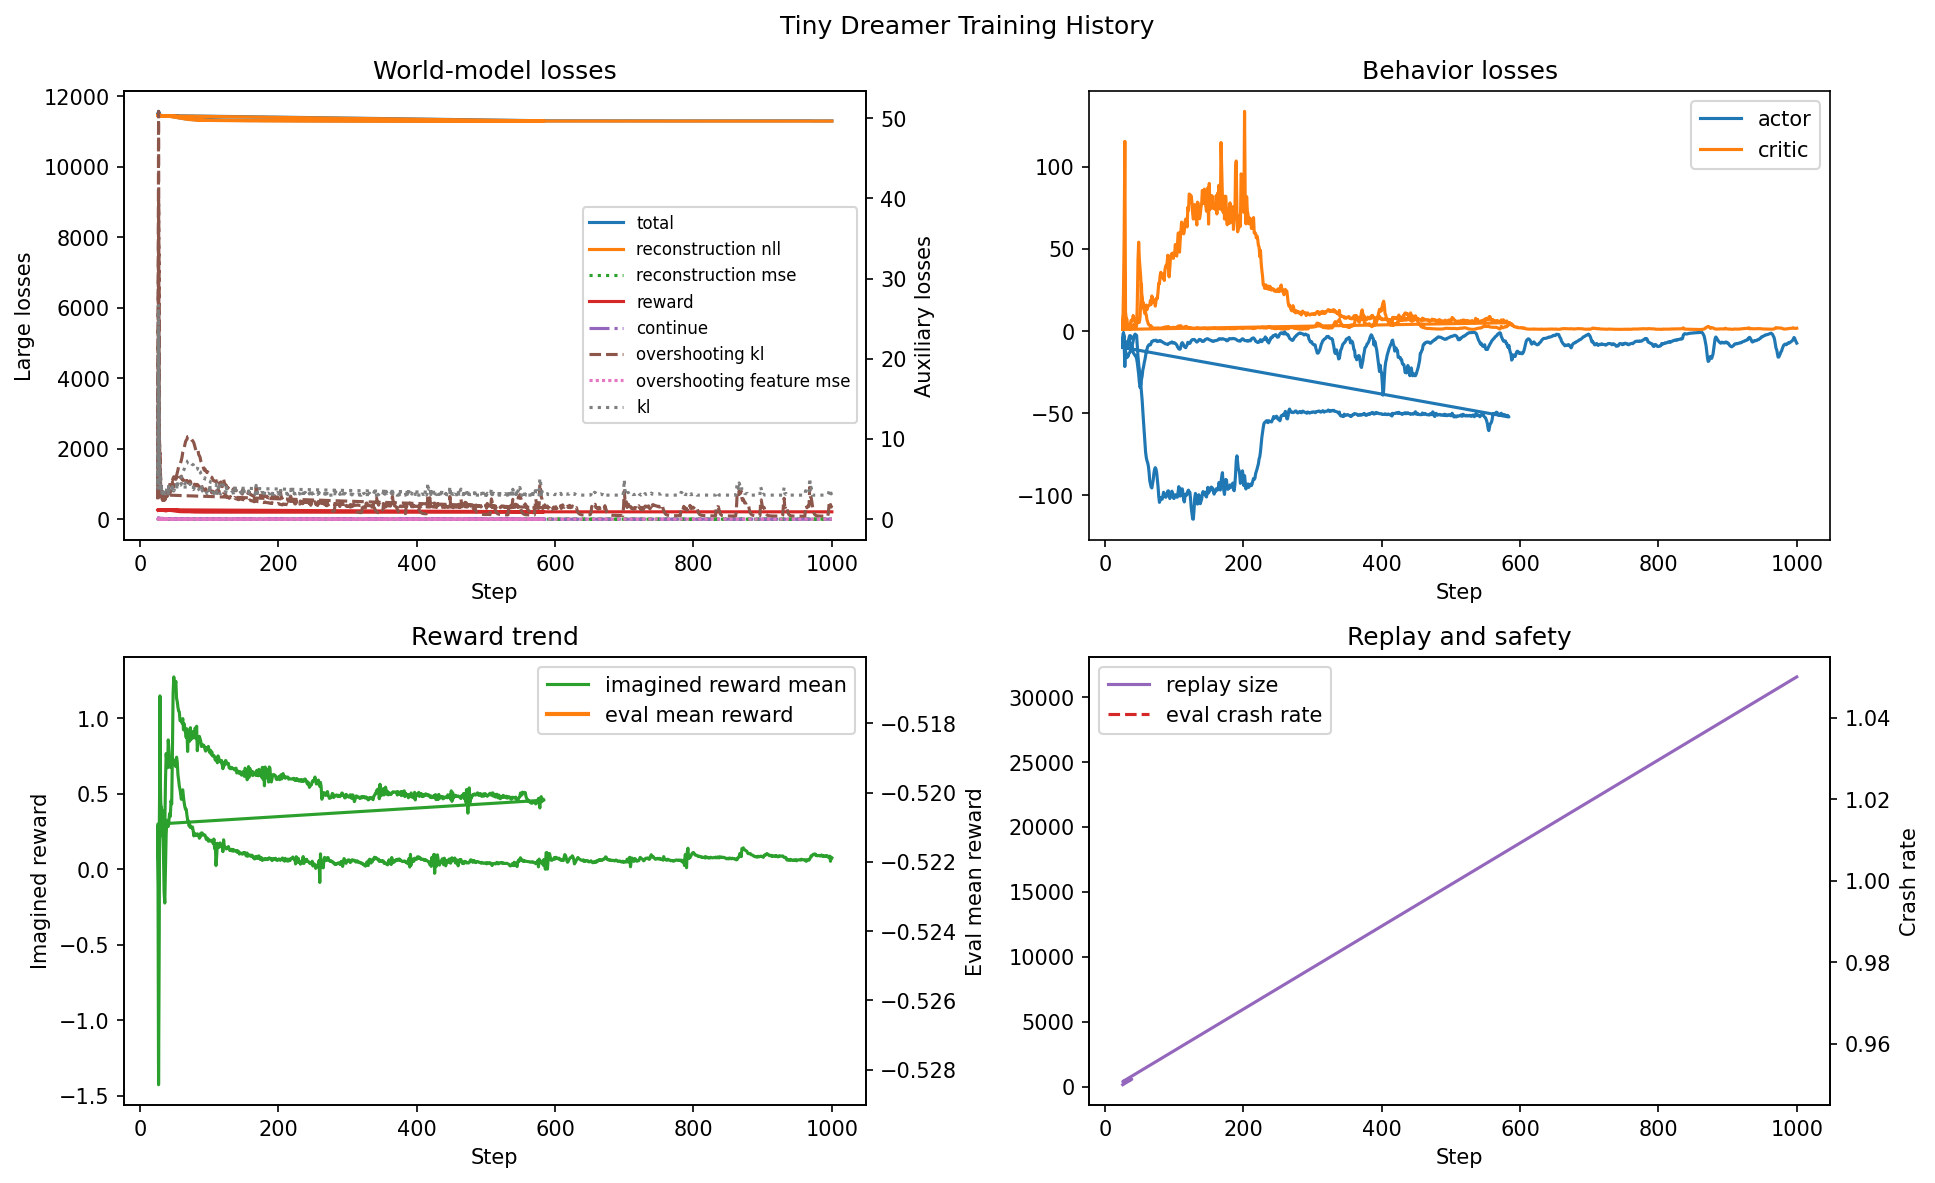

{'analysis_summary': {'best_eval_mean_reward': -0.5166618160530925,
  'best_eval_reward_step': 425,
  'best_imagined_reward_mean': 1.2744140625,
  'best_imagined_reward_step': 49,
  'best_world_model_step': 994,
  'best_world_model_total_loss': 11300.008056640625,
  'largest_replay_size': 31560,
  'largest_replay_step': 1000,
  'last_metrics': {'behavior/actor_loss': -7.3203125,
   'behavior/critic_loss': 1.7500445395708084,
   'behavior/imagined_reward_mean': 0.07586669921875,
   'behavior/imagined_value_mean': 6.16015625,
   'evaluation/crash_rate': 1.0,
   'evaluation/episodes': 10.0,
   'evaluation/mean_reward': -0.5193676050379873,
   'evaluation/mean_steps': 3.4,
   'policy_added': 32,
   'replay_size': 31560,
   'step': 1000,
   'warm_start_added': 0,
   'world_model/continue_loss': 2.1201318256558466e-08,
   'world_model/kl_loss': 3.2706722021102905,
   'world_model/kl_loss_raw': 2.728453427553177,
   'world_model/observation_log_prob': -11296.123291015625,
   'world_model/over

In [15]:
from IPython.display import Image, display
import csv
import importlib
import json
import tiny_dreamer_highway.evaluation.training_analysis as training_analysis

training_analysis = importlib.reload(training_analysis)
export_training_history_artifacts = training_analysis.export_training_history_artifacts

analysis_outputs = export_training_history_artifacts(
    training_summary.log_dir / 'cycle_metrics.csv',
    RUN_ARTIFACT_ROOT / 'analysis',
    prefix=RUN_NAME,
)

display(Image(filename=str(analysis_outputs['curves'])))
analysis_summary = json.loads(analysis_outputs['summary'].read_text(encoding='utf-8'))
with (training_summary.log_dir / 'cycle_metrics.csv').open('r', encoding='utf-8', newline='') as handle:
    metric_rows = list(csv.DictReader(handle))
latest_metrics_row = metric_rows[-1]
{
    'analysis_summary': analysis_summary,
    'phase4_metrics': {
        'world_model/reconstruction_loss': latest_metrics_row.get('world_model/reconstruction_loss'),
        'world_model/reconstruction_mse': latest_metrics_row.get('world_model/reconstruction_mse'),
        'world_model/observation_log_prob': latest_metrics_row.get('world_model/observation_log_prob'),
        'world_model/overshooting_kl_loss': latest_metrics_row.get('world_model/overshooting_kl_loss'),
        'world_model/overshooting_feature_mse': latest_metrics_row.get('world_model/overshooting_feature_mse'),
        'evaluation/mean_reward': latest_metrics_row.get('evaluation/mean_reward'),
        'evaluation/crash_rate': latest_metrics_row.get('evaluation/crash_rate'),
    },
}

## Agent Driving Demo

Record agent-driving GIFs using the trained policy from this run. These show the actor driving in the real highway-env.

Using demo recorder from: tiny_dreamer_highway.evaluation.policy_rollout
[demo] episode 1/10 | steps=2 | reward=-0.51 | CRASH | saved iter22_low_steering_penalty_ep01.gif
[demo] episode 2/10 | steps=4 | reward=-0.52 | CRASH | saved iter22_low_steering_penalty_ep02.gif
[demo] episode 3/10 | steps=2 | reward=-0.51 | CRASH | saved iter22_low_steering_penalty_ep03.gif
[demo] episode 4/10 | steps=5 | reward=-0.53 | CRASH | saved iter22_low_steering_penalty_ep04.gif
[demo] episode 5/10 | steps=2 | reward=-0.51 | CRASH | saved iter22_low_steering_penalty_ep05.gif
[demo] episode 6/10 | steps=5 | reward=-0.53 | CRASH | saved iter22_low_steering_penalty_ep06.gif
[demo] episode 7/10 | steps=4 | reward=-0.52 | CRASH | saved iter22_low_steering_penalty_ep07.gif
[demo] episode 8/10 | steps=5 | reward=-0.53 | CRASH | saved iter22_low_steering_penalty_ep08.gif
[demo] episode 9/10 | steps=4 | reward=-0.52 | CRASH | saved iter22_low_steering_penalty_ep09.gif
[demo] episode 10/10 | steps=5 | reward=-0.53

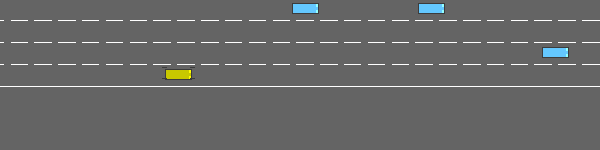


iter22_low_steering_penalty_ep02.gif


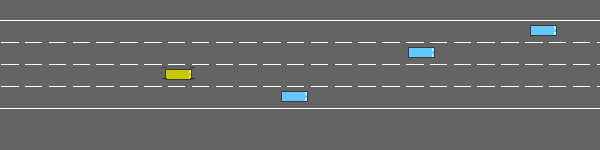


iter22_low_steering_penalty_ep03.gif


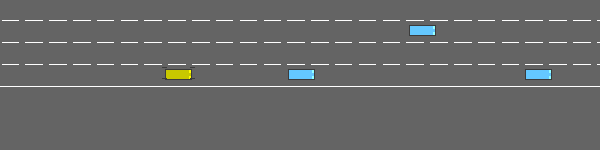


iter22_low_steering_penalty_ep04.gif


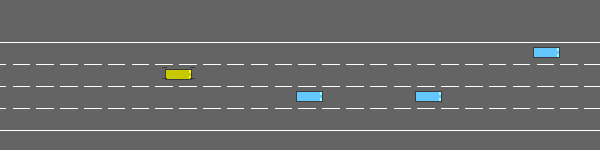


iter22_low_steering_penalty_ep05.gif


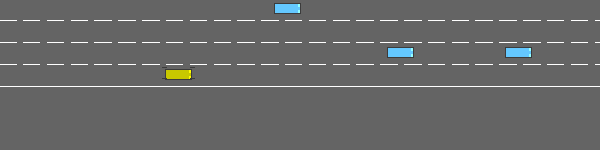


iter22_low_steering_penalty_ep06.gif


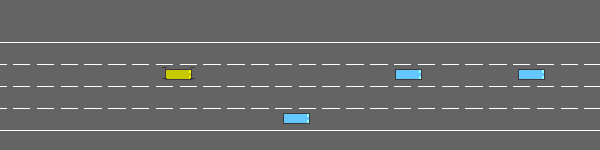


iter22_low_steering_penalty_ep07.gif


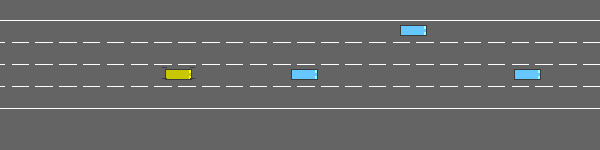


iter22_low_steering_penalty_ep08.gif


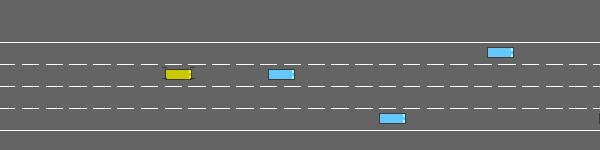


iter22_low_steering_penalty_ep09.gif


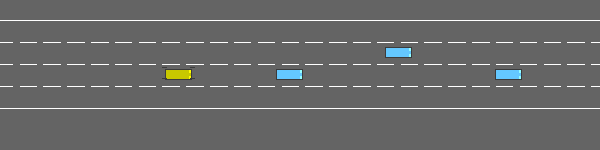


iter22_low_steering_penalty_ep10.gif


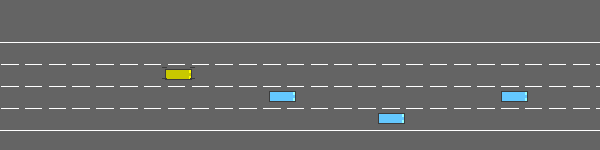

In [16]:
from IPython.display import Image, display
import importlib
import tiny_dreamer_highway.evaluation as evaluation_pkg

try:
    evaluation_pkg = importlib.reload(evaluation_pkg)
    record_demo_videos = evaluation_pkg.record_demo_videos
except (AttributeError, ImportError):
    from tiny_dreamer_highway.evaluation.policy_rollout import record_demo_videos

print('Using demo recorder from:', record_demo_videos.__module__)

demo_outputs = record_demo_videos(
    config,
    checkpoint_path=training_summary.latest_checkpoint,
    output_dir=RUN_ARTIFACT_ROOT / 'demo_videos',
    num_episodes=10,
    max_steps=1000,
    fps=15,
    seed=132,
    prefix=RUN_NAME,
    device=config.device,
)

for gif_path in demo_outputs.video_paths:
    print(f'\n{gif_path.name}')
    display(Image(filename=str(gif_path)))